# 🧪 Notebook 02: So Sánh 6 Variant Benchmark BAF (NeurIPS 2022)

> **Mục tiêu**: Phân tích sự khác biệt giữa 6 variant (`Base.csv`, `Variant I.csv` ... `Variant V.csv`), đánh giá **temporal dynamics** (biến `month`) và **distribution shifts** giữa các biến thể dữ liệu.


In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

variants = ["Base.csv", "Variant I.csv", "Variant II.csv", "Variant III.csv", "Variant IV.csv", "Variant V.csv"]
variant_dfs = {}

for v in variants:
    path = RAW_DATA_DIR / v
    if path.exists():
        print(f"Loading {v} ...")
        variant_dfs[v] = pd.read_csv(path)
    else:
        print(f"⚠️ Warning: {v} not found!")

print(f"Đã load {len(variant_dfs)} variants.")


Loading Base.csv ...
Loading Variant I.csv ...
Loading Variant II.csv ...
Loading Variant III.csv ...
Loading Variant IV.csv ...
Loading Variant V.csv ...
Đã load 6 variants.


## 1. So Sánh Quy Mô Dữ Liệu & Tỷ Lệ Fraud Giữa Các Variant


    Variant   Số dòng Số ca Fraud  Tỷ lệ Fraud (%)
       Base 1,000,000      11,029            1.103
  Variant I 1,000,000      11,029            1.103
 Variant II 1,000,000      11,029            1.103
Variant III 1,000,000      11,030            1.103
 Variant IV 1,000,000      11,030            1.103
  Variant V 1,000,000      11,030            1.103


/tmp/ipykernel_47312/158775460.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats_df, x='Variant', y='Tỷ lệ Fraud (%)', palette='Reds_d')


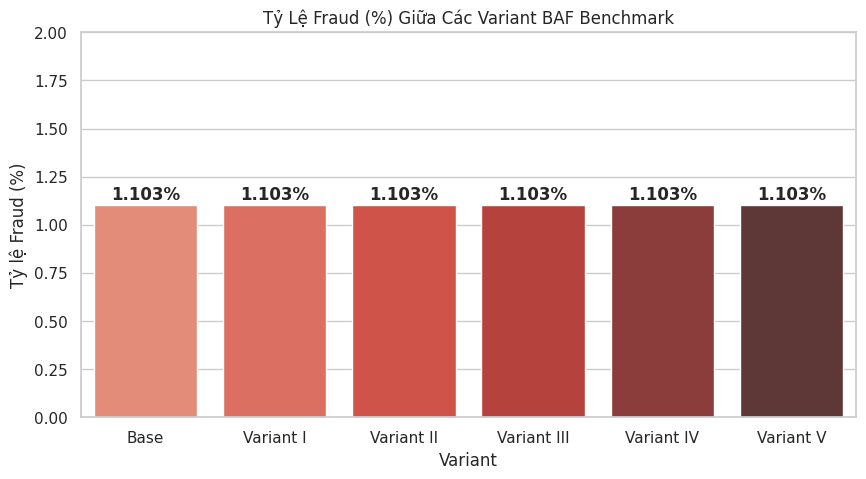

In [3]:
stats = []
for name, vdf in variant_dfs.items():
    n_rows = len(vdf)
    n_fraud = vdf['fraud_bool'].sum()
    fraud_rate = (n_fraud / n_rows) * 100
    stats.append({
        'Variant': name.replace('.csv', ''),
        'Số dòng': f"{n_rows:,}",
        'Số ca Fraud': f"{n_fraud:,}",
        'Tỷ lệ Fraud (%)': round(fraud_rate, 3)
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=stats_df, x='Variant', y='Tỷ lệ Fraud (%)', palette='Reds_d')
plt.title('Tỷ Lệ Fraud (%) Giữa Các Variant BAF Benchmark')
plt.ylim(0, 2.0)
for i, row in stats_df.iterrows():
    plt.text(i, row['Tỷ lệ Fraud (%)'] + 0.03, f"{row['Tỷ lệ Fraud (%)']}%", ha='center', fontweight='bold')
plt.show()


## 2. Temporal Dynamics: Fraud Rate Theo Thời Gian (`month` 0 đến 7)


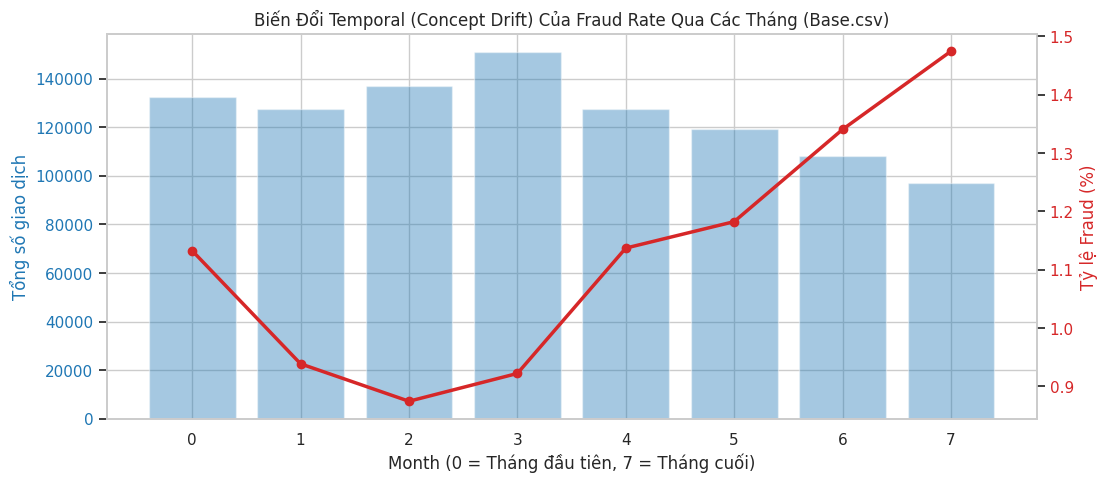

In [4]:
base_df = variant_dfs["Base.csv"]
monthly_stats = base_df.groupby('month')['fraud_bool'].agg(['count', 'sum', 'mean']).reset_index()
monthly_stats['fraud_rate_%'] = monthly_stats['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Month (0 = Tháng đầu tiên, 7 = Tháng cuối)')
ax1.set_ylabel('Tổng số giao dịch', color=color)
ax1.bar(monthly_stats['month'], monthly_stats['count'], color=color, alpha=0.4, label='Số giao dịch')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Tỷ lệ Fraud (%)', color=color)
ax2.plot(monthly_stats['month'], monthly_stats['fraud_rate_%'], color=color, marker='o', linewidth=2.5, label='Fraud Rate (%)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Biến Đổi Temporal (Concept Drift) Của Fraud Rate Qua Các Tháng (Base.csv)')
plt.grid(False)
plt.show()


## 3. So Sánh Bias Nhóm Tuổi (`customer_age`) Giữa Base vs Variant I vs Variant II


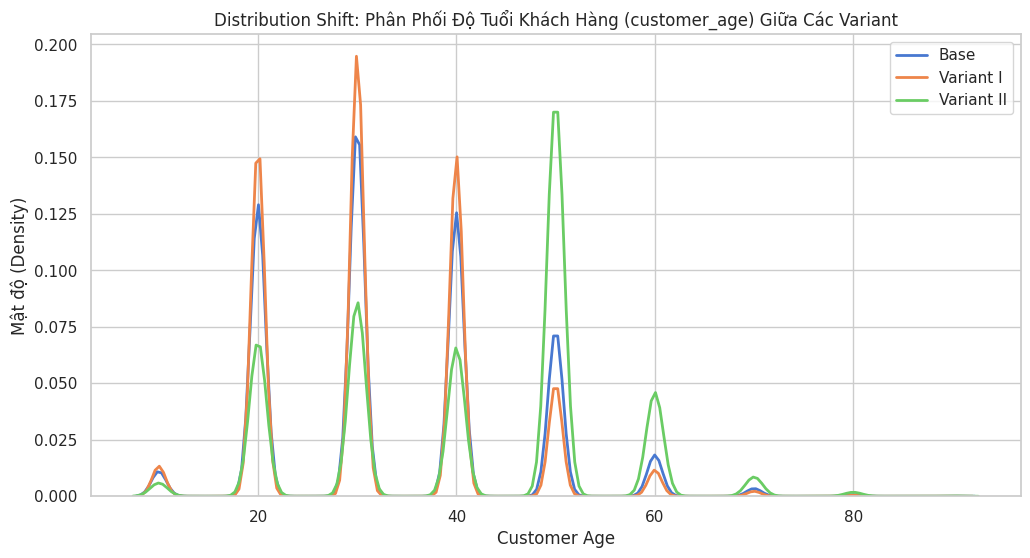

In [5]:
comparison_variants = ["Base.csv", "Variant I.csv", "Variant II.csv"]

plt.figure(figsize=(12, 6))
for v_name in comparison_variants:
    if v_name in variant_dfs:
        v_df = variant_dfs[v_name]
        sns.kdeplot(v_df['customer_age'], label=v_name.replace('.csv', ''), linewidth=2)

plt.title('Distribution Shift: Phân Phối Độ Tuổi Khách Hàng (customer_age) Giữa Các Variant')
plt.xlabel('Customer Age')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.show()
